## 02. Scratchpad

### 1. File handling via Data.py 

In [1]:
import Data
import matplotlib.pyplot as plt

In [14]:
path = '../data/tatoeba_1/eng-pol_1.tsv'
df = Data.upload_tsv(path=path, col_drop=[0, 2])
df.head(3)

,eng_text,pol_text
0,Let's try something.,Spróbujmy coś.
1,I have to go to sleep.,Muszę iść spać.
2,Muiriel is 20 now.,Muiriel ma teraz 20 lat.


In [15]:
df_tok = Data.tokenize_data(df=df, src_col='eng_text', tgt_col='pol_text')
df_tok.head(3)

,eng_text,pol_text,eng_len,pol_len
0,"[lets, try, something, ., <eos>]","[<bos>, spróbujmy, coś, ., <eos>]",5,5
1,"[i, have, to, go, to, sleep, ., <eos>]","[<bos>, muszę, iść, spać, ., <eos>]",8,6
2,"[muiriel, is, 20, now, ., <eos>]","[<bos>, muiriel, ma, teraz, 20, lat, ., <eos>]",6,8


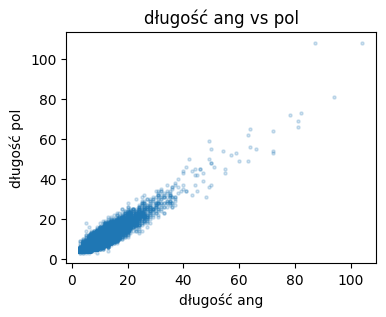

In [16]:
plt.figure(figsize=(4, 3))
plt.scatter(df_tok['eng_len'], df_tok['pol_len'], alpha=0.2, s=5)
plt.xlabel('długość ang')
plt.ylabel('długość pol')
plt.title('długość ang vs pol')
plt.show()

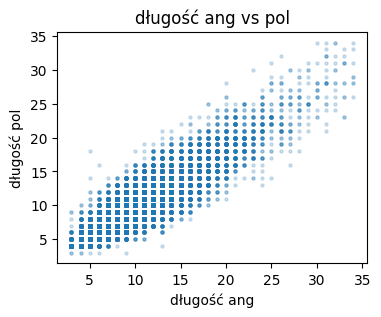

In [17]:
df_trim = Data.trim_data(df=df_tok, src_len='eng_len', tgt_len='pol_len', thres=34)
plt.figure(figsize=(4, 3))
plt.scatter(df_trim['eng_len'], df_trim['pol_len'], alpha=0.2, s=5)
plt.xlabel('długość ang')
plt.ylabel('długość pol')
plt.title('długość ang vs pol')
plt.show()

In [18]:
df_ids, eng_vocab, pol_vocab = Data.tokens_to_id(df=df_trim, src_col='eng_text', tgt_col='pol_text')
df_ids.head(3)

,eng_text,pol_text,eng_len,pol_len,src_ids,tgt_ids
0,"[lets, try, something, ., <eos>]","[<bos>, spróbujmy, coś, ., <eos>]",5,5,"[157, 271, 122, 3, 2]","[3, 3407, 68, 4, 2]"
1,"[i, have, to, go, to, sleep, ., <eos>]","[<bos>, muszę, iść, spać, ., <eos>]",8,6,"[5, 20, 6, 54, 6, 329, 3, 2]","[3, 89, 103, 293, 4, 2]"
2,"[muiriel, is, 20, now, ., <eos>]","[<bos>, muiriel, ma, teraz, 20, lat, ., <eos>]",6,8,"[3447, 11, 1744, 94, 3, 2]","[3, 4377, 26, 75, 1344, 115, 4, 2]"


In [19]:
df_data = df_ids[['src_ids', 'tgt_ids']]
df_data.head(3)

,src_ids,tgt_ids
0,"[157, 271, 122, 3, 2]","[3, 3407, 68, 4, 2]"
1,"[5, 20, 6, 54, 6, 329, 3, 2]","[3, 89, 103, 293, 4, 2]"
2,"[3447, 11, 1744, 94, 3, 2]","[3, 4377, 26, 75, 1344, 115, 4, 2]"


In [20]:
df_train, df_val = Data.shuffle_split(df=df_data, tr_per=0.8)
print(df_train.shape, df_val.shape)
df_train.head(3)

(67045, 2) (16762, 2)


,src_ids,tgt_ids
0,"[4, 868, 24, 1, 447, 4, 233, 682, 3, 2]","[3, 3210, 11452, 1, 186, 4298, 1511, 4, 2]"
1,"[48, 1377, 3, 2]","[3, 17165, 4, 2]"
2,"[5, 118, 561, 1263, 3, 2]","[3, 86, 2038, 967, 4, 2]"


In [21]:
train_data = Data.EngPolDataset(df_train, 'src_ids', 'tgt_ids')
val_data = Data.EngPolDataset(df_val, 'src_ids', 'tgt_ids')

### 2. Training Transformers Model

In [22]:
import Model
import Trainer
import Predict

In [23]:
num_hiddens, num_blks, dropout = 256, 2, 0.2
ffn_num_hiddens, num_heads = 512, 4

encoder = Model.TransformerEncoder(len(eng_vocab), num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout)
decoder = Model.TransformerDecoder(len(pol_vocab), num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout)
model = Model.Seq2Seq(encoder=encoder, decoder=decoder, lr=0.001, pad_id=0, device='cuda')

In [24]:
trainer = Trainer.TrainerModule(batch_size=64)
trainer.plotter_init("Test 1")

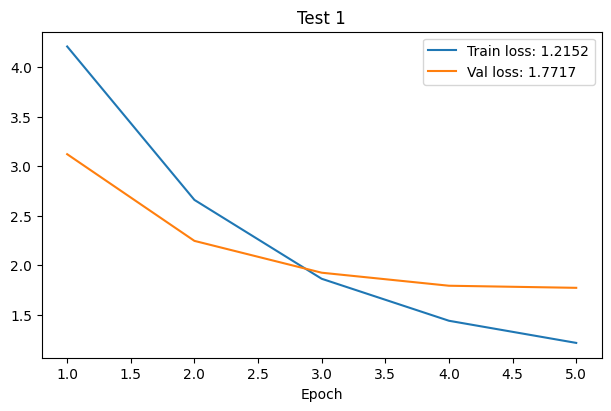

In [25]:
trainer.fit(model, train_data, val_data, 5, '../checkpoints/checkpoint.pt')

### 3. Predicting On Transformers Model

In [34]:
next(model.parameters())

Parameter containing:
tensor([[ 0.1266, -1.1170,  0.4638,  ...,  0.5693,  0.1267, -0.5055],
        [ 0.9145,  1.5503, -0.1600,  ..., -1.0592, -0.0345, -0.3763],
        [ 0.1237,  0.5317, -1.3245,  ..., -0.6944, -0.2920,  1.4651],
        ...,
        [ 1.1070, -0.1761, -0.8834,  ...,  1.0499, -2.1749, -0.1615],
        [-1.8852,  0.8467,  0.8114,  ...,  0.7479, -0.6612,  0.6804],
        [-0.8028,  1.6083, -0.3018,  ...,  0.3575,  1.5435,  1.7539]],
       device='cuda:0', requires_grad=True)

In [ ]:
model_2 = 

In [27]:
pol_vocab_rev = {v: k for k, v in pol_vocab.items()}
pol_vocab_rev

{0: '<pad>',
 1: '<unk>',
 2: '<eos>',
 3: '<bos>',
 4: '.',
 5: ',',
 6: 'nie',
 7: '?',
 8: 'się',
 9: 'tom',
 10: 'jest',
 11: 'to',
 12: 'w',
 13: 'na',
 14: 'że',
 15: 'do',
 16: 'z',
 17: 'czy',
 18: 'co',
 19: 'i',
 20: 'jak',
 21: 'o',
 22: 'mi',
 23: 'mnie',
 24: '!',
 25: 'mary',
 26: 'ma',
 27: 'on',
 28: 'jestem',
 29: 'po',
 30: 'tego',
 31: 'za',
 32: 'są',
 33: 'mam',
 34: 'jesteś',
 35: 'był',
 36: 'bardzo',
 37: 'tak',
 38: 'toma',
 39: 'ten',
 40: 'ci',
 41: 'od',
 42: 'tym',
 43: 'ona',
 44: 'już',
 45: 'mogę',
 46: 'zrobić',
 47: 'go',
 48: 'cię',
 49: 'chcę',
 50: 'nigdy',
 51: 'mój',
 52: 'kiedy',
 53: 'być',
 54: 'dla',
 55: 'może',
 56: 'jego',
 57: 'ale',
 58: 'domu',
 59: 'tylko',
 60: 'gdzie',
 61: 'tu',
 62: 'jej',
 63: 'żeby',
 64: 'będzie',
 65: 'było',
 66: 'masz',
 67: 'wiem',
 68: 'coś',
 69: 'powiedział',
 70: 'dlaczego',
 71: 'kto',
 72: 'przez',
 73: 'wszystko',
 74: 'proszę',
 75: 'teraz',
 76: 'ze',
 77: 'sobie',
 78: 'jeszcze',
 79: 'nic',
 80: 'z

In [28]:
Predict.predict_step("John likes reading books.", eng_vocab, pol_vocab, pol_vocab_rev, model)

NameError: name 'tokenize_eng' is not defined